In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
target = "Churn"
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

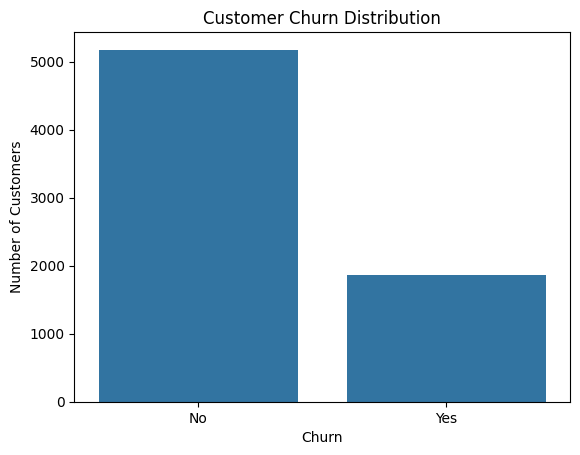

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

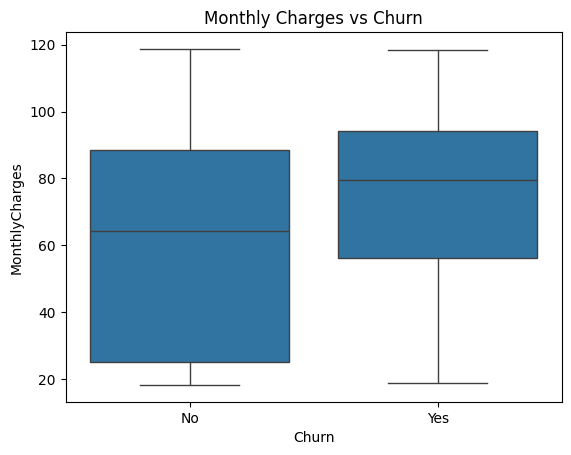

In [10]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.show()

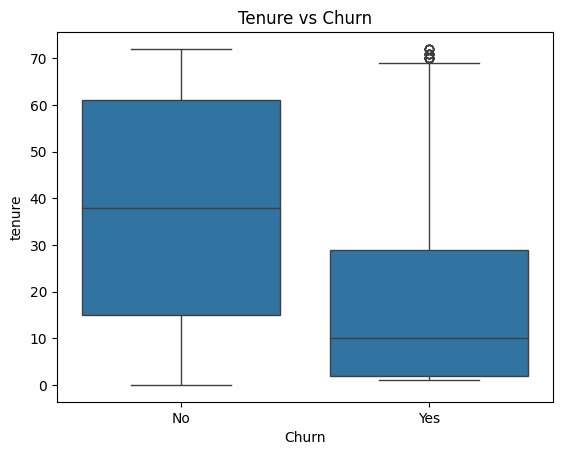

In [11]:
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Churn")
plt.show()

In [12]:
df["TotalCharges"].dtype

dtype('O')

In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [15]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
print("Missing TotalCharges:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges: 0


In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [21]:
df = df.drop(columns=["customerID"])

In [22]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [24]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
y = y.map({
    "No": 0,
    "Yes": 1
})

In [25]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(7043, 19)
(7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [26]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5634, 19)
Testing: (1409, 19)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [31]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [32]:
y_pred = logistic_pipeline.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664
ROC-AUC  : 0.8421349040274871


In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df_clean = df.copy()

In [36]:
df_clean

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [37]:
df_clean.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [38]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [40]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [41]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [42]:
df_clean[df_clean["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [43]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [44]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [45]:
missing = df_clean.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [46]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [47]:
print(
    "Duplicate customer IDs:",
    df_clean["customerID"].duplicated().sum()
)

Duplicate customer IDs: 0


In [48]:
print(df_clean["gender"].unique())
print(df_clean["Partner"].unique())
print(df_clean["Dependents"].unique())
print(df_clean["Churn"].unique())

['Female' 'Male']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']


In [49]:
print(df_clean["tenure"].describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [50]:
print("Negative tenure:",
      (df_clean["tenure"] < 0).sum())

Negative tenure: 0


In [51]:
print(df_clean["MonthlyCharges"].describe())

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [52]:
print("Negative MonthlyCharges:",
      (df_clean["MonthlyCharges"] < 0).sum())

Negative MonthlyCharges: 0


In [53]:
print(df_clean["TotalCharges"].describe())

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [54]:
print("Negative TotalCharges:",
      (df_clean["TotalCharges"] < 0).sum())

Negative TotalCharges: 0


In [55]:
target = "Churn"
df_clean["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [56]:
df_clean["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [57]:
df_clean = df_clean.drop(columns=["customerID"])

In [58]:
print(df_clean.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [59]:
print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

Shape: (7043, 20)

Missing values:
0

Duplicate rows:
22

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [60]:
df_clean[df_clean.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [61]:
print("Before:", df_clean.shape)

Before: (7043, 20)


In [62]:
df_clean = df_clean.drop_duplicates()

In [63]:
print("After:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())

After: (7021, 20)
Duplicate rows: 0


In [64]:
print("Shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Shape: (7021, 20)
Missing values: 0
Duplicate rows: 0


In [65]:
df_clean["AverageMonthlySpend"] = np.where(
    df_clean["tenure"] > 0,
    df_clean["TotalCharges"] / df_clean["tenure"],
    0
)

In [66]:
df_clean[
    ["tenure", "TotalCharges", "AverageMonthlySpend"]
].head()

,tenure,TotalCharges,AverageMonthlySpend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


In [67]:
df_clean["IsNewCustomer"] = (
    df_clean["tenure"] <= 3
).astype(int)

In [68]:
df_clean["IsNewCustomer"].value_counts()

IsNewCustomer
0    5981
1    1040
Name: count, dtype: int64

In [69]:
df_clean["HasLongTermContract"] = (
    df_clean["Contract"] != "Month-to-month"
).astype(int)

In [70]:
df_clean[
    ["Contract", "HasLongTermContract"]
].head()

,Contract,HasLongTermContract
0,Month-to-month,0
1,One year,1
2,Month-to-month,0
3,One year,1
4,Month-to-month,0


In [71]:
print("Shape:", df_clean.shape)
df_clean.head()

Shape: (7021, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,IsNewCustomer,HasLongTermContract
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1,0


In [72]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [73]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7021, 22)
y shape: (7021,)

Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5616, 22)
X_test : (1405, 22)
y_train: (5616,)
y_test : (1405,)


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [77]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train:", X_train_processed.shape)
print("Test :", X_test_processed.shape)

Train: (5616, 48)
Test : (1405, 48)


In [78]:
preprocessor.fit_transform(X_train)

array([[-0.44031529, -1.24133083,  0.19316451, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44031529, -0.71107812,  0.64735514, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44031529,  1.40993271,  0.82038014, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.44031529,  1.04283468,  1.3827114 , ...,  0.        ,
         1.        ,  0.        ],
       [ 2.2710999 ,  1.57308739,  1.15644794, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44031529, -0.01767073, -1.50214778, ...,  0.        ,
         0.        ,  0.        ]], shape=(5616, 48))

In [79]:
preprocessor.transform(X_test)

array([[ 2.2710999 , -1.03738748,  0.33125177, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.2710999 , -0.54792344,  1.03167029, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44031529, -1.2821195 , -0.63036796, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.44031529,  0.39021597, -1.50880259, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44031529, -0.54792344,  0.73054024, ...,  0.        ,
         1.        ,  0.        ],
       [-0.44031529, -1.24133083, -1.50214778, ...,  0.        ,
         0.        ,  1.        ]], shape=(1405, 48))

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_processed, y_train)

    trained_models[name] = model

print("\nAll 5 models trained successfully! ✅")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training SVM...


C:\Users\ganes\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



All 5 models trained successfully! ✅


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802847,0.664360,0.516129,0.580938,0.841550
1,Decision Tree,0.790747,0.632653,0.500000,0.558559,0.828134
2,Random Forest,0.775089,0.568293,0.626344,0.595908,0.820944
3,XGBoost,0.790036,0.632302,0.494624,0.555053,0.838784
4,SVM,0.797865,0.657143,0.494624,0.564417,0.781419


In [82]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802847,0.664360,0.516129,0.580938,0.841550
3,XGBoost,0.790036,0.632302,0.494624,0.555053,0.838784
1,Decision Tree,0.790747,0.632653,0.500000,0.558559,0.828134
2,Random Forest,0.775089,0.568293,0.626344,0.595908,0.820944
4,SVM,0.797865,0.657143,0.494624,0.564417,0.781419


In [83]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1:", best_model_name)

Best model based on F1: Random Forest


In [84]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample", None]
}
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....0013C9174F750>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimato

In [85]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 341}


In [86]:
print("Best CV F1 Score:")
print(random_search.best_score_)

Best CV F1 Score:
0.6277234614370275


In [87]:
best_rf = random_search.best_estimator_

In [88]:
rf_pred = best_rf.predict(X_test_processed)

rf_prob = best_rf.predict_proba(
    X_test_processed
)[:, 1]

In [89]:
print("Tuned Random Forest")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Tuned Random Forest
-------------------
Accuracy : 0.7800711743772242
Precision: 0.5686274509803921
Recall   : 0.7016129032258065
F1 Score : 0.628158844765343
ROC-AUC  : 0.8387864451592084


In [90]:
before_tuning = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

print("Before tuning")
print("F1 Score:", before_tuning["F1 Score"])
print("ROC-AUC :", before_tuning["ROC-AUC"])

print("\nAfter tuning")
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf_prob))

Before tuning
F1 Score: 0.5959079283887468
ROC-AUC : 0.8209438008098346

After tuning
F1 Score: 0.628158844765343
ROC-AUC : 0.8387864451592084


[[835 198]
 [111 261]]


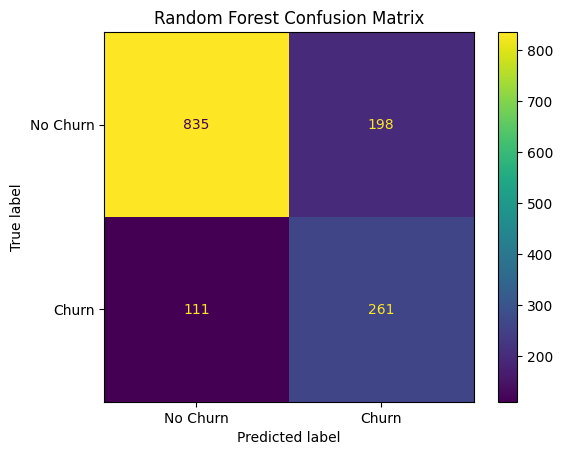

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [92]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1033
       Churn       0.57      0.70      0.63       372

    accuracy                           0.78      1405
   macro avg       0.73      0.75      0.74      1405
weighted avg       0.80      0.78      0.79      1405



In [93]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ganes\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [94]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [95]:
explainer = shap.TreeExplainer(best_rf)

print("SHAP explainer created successfully! ✅")

SHAP explainer created successfully! ✅


In [96]:
shap_values = explainer.shap_values(X_test_processed)

print("SHAP values calculated successfully! ✅")

SHAP values calculated successfully! ✅


In [97]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("Shape:", shap_values[1].shape)
else:
    print("Shape:", shap_values.shape)

<class 'numpy.ndarray'>
Shape: (1405, 48, 2)


In [98]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 48
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__AverageMonthlySpend' 'num__IsNewCustomer'
 'num__HasLongTermContract' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic']


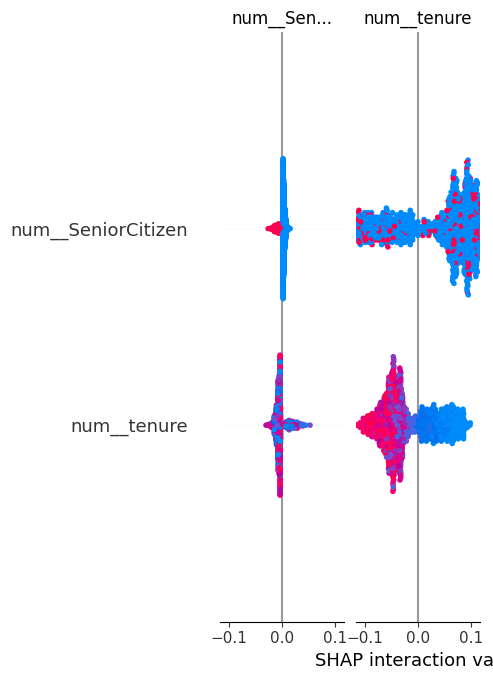

In [99]:
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test_processed,
        feature_names=feature_names
    )
else:
    shap.summary_plot(
        shap_values,
        X_test_processed,
        feature_names=feature_names
    )

In [100]:
customer_index = 0

# SHAP values for this customer and Churn class
customer_shap = shap_values[customer_index, :, 1]

# Base value for Churn class
base_value = explainer.expected_value[1]

# Customer data
customer_data = X_test_processed[customer_index]

print("SHAP values shape:", customer_shap.shape)
print("Base value:", base_value)

SHAP values shape: (48,)
Base value: 0.49999999999999967


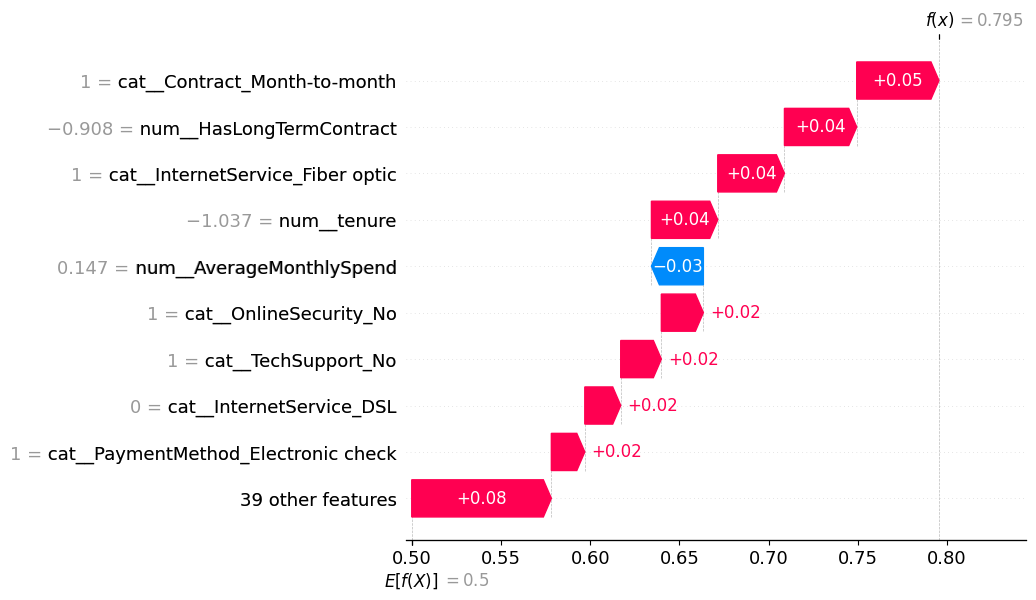

In [101]:
shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=base_value,
        data=customer_data,
        feature_names=feature_names
    )
)

In [102]:
shap_values

array([[[-0.00684317,  0.00684317],
        [-0.03716356,  0.03716356],
        [ 0.00784923, -0.00784923],
        ...,
        [-0.0028342 ,  0.0028342 ],
        [-0.01874078,  0.01874078],
        [-0.00170377,  0.00170377]],

       [[-0.01052956,  0.01052956],
        [ 0.03367641, -0.03367641],
        [-0.01773007,  0.01773007],
        ...,
        [ 0.01608917, -0.01608917],
        [ 0.02966625, -0.02966625],
        [-0.00065488,  0.00065488]],

       [[ 0.00362136, -0.00362136],
        [-0.09242086,  0.09242086],
        [ 0.01111426, -0.01111426],
        ...,
        [-0.00095298,  0.00095298],
        [ 0.02359547, -0.02359547],
        [ 0.01068229, -0.01068229]],

       ...,

       [[ 0.00187165, -0.00187165],
        [ 0.03753816, -0.03753816],
        [ 0.03201695, -0.03201695],
        ...,
        [-0.0016025 ,  0.0016025 ],
        [ 0.01771864, -0.01771864],
        [ 0.00447846, -0.00447846]],

       [[ 0.00561084, -0.00561084],
        [ 0.03118461, -0.03

In [103]:
shap_values_churn = shap_values[:, :, 1]

print(shap_values_churn.shape)

(1405, 48)


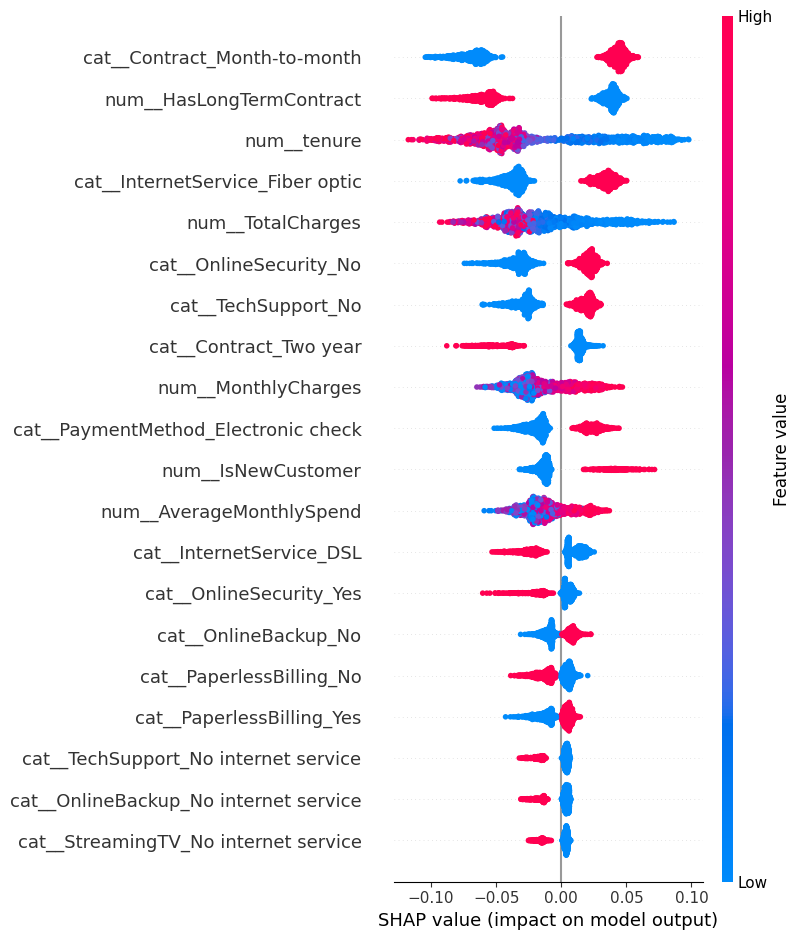

In [104]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values_churn,
    X_test_processed,
    feature_names=feature_names
)

In [105]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(shap_values_churn).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
39,cat__Contract_Month-to-month,0.055202
6,num__HasLongTermContract,0.048769
1,num__tenure,0.048344
19,cat__InternetService_Fiber optic,0.036435
3,num__TotalCharges,0.031082
21,cat__OnlineSecurity_No,0.027661
30,cat__TechSupport_No,0.024370
41,cat__Contract_Two year,0.022687
2,num__MonthlyCharges,0.022110
46,cat__PaymentMethod_Electronic check,0.021228


In [106]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_rf, "models/random_forest_churn.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Model saved successfully! ✅")
print("Preprocessor saved successfully! ✅")

Model saved successfully! ✅
Preprocessor saved successfully! ✅


In [107]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [108]:
mlflow.set_experiment("Telco_Customer_Churn")

<Experiment: artifact_location='file:D:/MLprojects/explainable-tabular-ml-engine/notebooks/mlruns/1', creation_time=1789395328227, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789395328227, lifecycle_stage='active', name='Telco_Customer_Churn', tags={}, trace_location=None, workspace='default'>

In [109]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Telco_Customer_Churn")

print("Experiment configured successfully! ✅")

Experiment configured successfully! ✅


In [110]:
with mlflow.start_run(run_name="RandomForest_Tuned"):

    mlflow.log_param(
        "model",
        "RandomForestClassifier"
    )

    mlflow.log_param(
        "tuning_method",
        "RandomizedSearchCV"
    )

    mlflow.log_param(
        "cv",
        5
    )

    mlflow.log_params(best_rf.get_params())

    mlflow.log_metric(
        "accuracy",
        accuracy_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "precision",
        precision_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "recall",
        recall_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "f1",
        f1_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(y_test, rf_prob)
    )

    mlflow.sklearn.log_model(
    best_rf,
    name="random_forest_model"
)

print("MLflow run completed! ✅")

MLflow run completed! ✅


In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Telco_Customer_Churn")

print("Experiment:", mlflow.get_experiment_by_name("Telco_Customer_Churn"))

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

print("Tracking URI:")
print(mlflow.get_tracking_uri())

In [ ]:
experiment = mlflow.get_experiment_by_name("Telco_Customer_Churn")

print(experiment)

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("Telco_Customer_Churn")

with mlflow.start_run(run_name="Test_Run"):
    mlflow.log_param("test", "hello")
    mlflow.log_metric("accuracy", 0.78)

    print("Run ID:", mlflow.active_run().info.run_id)

print("TEST RUN COMPLETED")

In [ ]:
print(best_rf)

In [ ]:
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

In [ ]:
with mlflow.start_run(run_name="RandomForest_Tuned"):

    mlflow.log_param("model", "Random Forest")

    mlflow.log_metric("accuracy", accuracy_score(y_test, rf_pred))
    mlflow.log_metric("precision", precision_score(y_test, rf_pred))
    mlflow.log_metric("recall", recall_score(y_test, rf_pred))
    mlflow.log_metric("f1_score", f1_score(y_test, rf_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, rf_prob))

    mlflow.sklearn.log_model(
        best_rf,
        name="random_forest_model"
    )

    print("Run ID:", mlflow.active_run().info.run_id)

print("Real model logged to MLflow! ✅")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

with mlflow.start_run(run_name="RandomForest_Tuned"):

    # =========================
    # 1. MODEL INFORMATION
    # =========================

    mlflow.log_param(
        "model",
        "RandomForestClassifier"
    )

    mlflow.log_param(
        "tuning_method",
        "RandomizedSearchCV"
    )

    mlflow.log_param(
        "cv_folds",
        5
    )

    # =========================
    # 2. BEST HYPERPARAMETERS
    # =========================

    mlflow.log_params(best_rf.get_params())

    # =========================
    # 3. EVALUATION METRICS
    # =========================

    mlflow.log_metric(
        "accuracy",
        accuracy_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "precision",
        precision_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "recall",
        recall_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "f1_score",
        f1_score(y_test, rf_pred)
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(y_test, rf_prob)
    )

    # =========================
    # 4. SAVE MODEL TO MLflow
    # =========================

    mlflow.sklearn.log_model(
        best_rf,
        name="random_forest_model"
    )

    # =========================
    # 5. DISPLAY RUN ID
    # =========================

    print(
        "Run ID:",
        mlflow.active_run().info.run_id
    )

print("REAL RANDOM FOREST RUN COMPLETED! ✅")

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_rf,
    "models/random_forest_churn.pkl"
)

joblib.dump(
    preprocessor,
    "models/preprocessor.pkl"
)

print("Random Forest saved! ✅")
print("Preprocessor saved! ✅")

In [ ]:
shap_importance
shap_importance.to_csv(
    "models/shap_feature_importance.csv",
    index=False
)

print("SHAP importance saved! ✅")

In [ ]:
with mlflow.start_run(run_name="SHAP_Explainability"):

    mlflow.log_artifact(
        "models/shap_feature_importance.csv",
        artifact_path="shap"
    )

    print("SHAP artifact logged to MLflow! ✅")